In [1]:
#LIBRARY
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting 
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier                                                                                                           
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)                   
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import math
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, GaussianNoise
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
from sklearn.preprocessing import StandardScaler, MinMaxScaler
%run useful.py
import tensorflow.random as tf_r
import tensorflow as tf
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from sklearn.preprocessing import StandardScaler
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



XGBoost version: 3.2.0


I0000 00:00:1778749269.583628  157668 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778749269.738907  157668 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778749270.944930  157668 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


*Vanilla NN*                        

In [ ]:
#IMPORTING DATA ex3
mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13
np.random.seed(12345)

dname = "./DATA/"
str0 = "_XGB_26.dat"
fnamex = dname + 'x' + str0
fnamey = dname + 'y' + str0

x = np.loadtxt(fnamex, delimiter=" ", dtype=float)
y = np.loadtxt(fnamey)

y = y.astype(int)

N = len(x)         
L = len(x[0])      

print(f"N (samsple) = {N}")
print(f"L (feature) = {L}") 

feature_names = [f'Feature {i}' for i in range(L)] 

df_temp = pd.DataFrame(x, columns=feature_names)
df_temp['class'] = y
print(df_temp)

N (samsple) = 5000
L (feature) = 4
      Feature 0  Feature 1  Feature 2  Feature 3  class
0       -31.608    -29.544      6.773      9.554      0
1        46.451     15.318     24.891     15.357      0
2        24.771     46.131    -49.161    -39.356      0
3       -20.130     15.641     30.981     37.218      0
4        46.465     22.369     14.248     21.745      0
...         ...        ...        ...        ...    ...
4995     26.862      5.851    -15.226     16.201      0
4996     -9.849    -26.832      1.515     42.998      0
4997    -32.939      8.801    -28.160    -10.964      1
4998    -22.286     47.154     40.197     32.428      1
4999    -46.287    -27.454    -47.655     48.126      1

[5000 rows x 5 columns]


In [2]:
mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13
np.random.seed(12345)

# Percorso corretto del file
path = "./magic+gamma+telescope/magic04.data"

# Nomi delle feature basati sulla documentazione del dataset MAGIC
feature_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 
                 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']

# Carichiamo il dataset
# Il file non ha header, quindi passiamo i nomi manualmente
df = pd.read_csv(path, names=feature_names + ['class'], header=None)

# Mappiamo la classe testuale in numeri: g (gamma) -> 1, h (hadron) -> 0
df['class'] = df['class'].map({'g': 1, 'h': 0})

# Separiamo feature (x) e target (y)
x = df[feature_names].values
y = df['class'].values

N = len(x)         
L = len(x[0])      

print(f"N (samples) = {N}")
print(f"L (features) = {L}") 

# Visualizzazione del DataFrame finale
print(df)

N (samples) = 19020
L (features) = 10
        fLength    fWidth   fSize   fConc  fConc1     fAsym   fM3Long  \
0       28.7967   16.0021  2.6449  0.3918  0.1982   27.7004   22.0110   
1       31.6036   11.7235  2.5185  0.5303  0.3773   26.2722   23.8238   
2      162.0520  136.0310  4.0612  0.0374  0.0187  116.7410  -64.8580   
3       23.8172    9.5728  2.3385  0.6147  0.3922   27.2107   -6.4633   
4       75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277   28.5525   
...         ...       ...     ...     ...     ...       ...       ...   
19015   21.3846   10.9170  2.6161  0.5857  0.3934   15.2618   11.5245   
19016   28.9452    6.7020  2.2672  0.5351  0.2784   37.0816   13.1853   
19017   75.4455   47.5305  3.4483  0.1417  0.0549   -9.3561   41.0562   
19018  120.5135   76.9018  3.9939  0.0944  0.0683    5.8043  -93.5224   
19019  187.1814   53.0014  3.2093  0.2876  0.1539 -167.3125 -168.4558   

       fM3Trans   fAlpha     fDist  class  
0       -8.2027  40.0920   81.8828      1

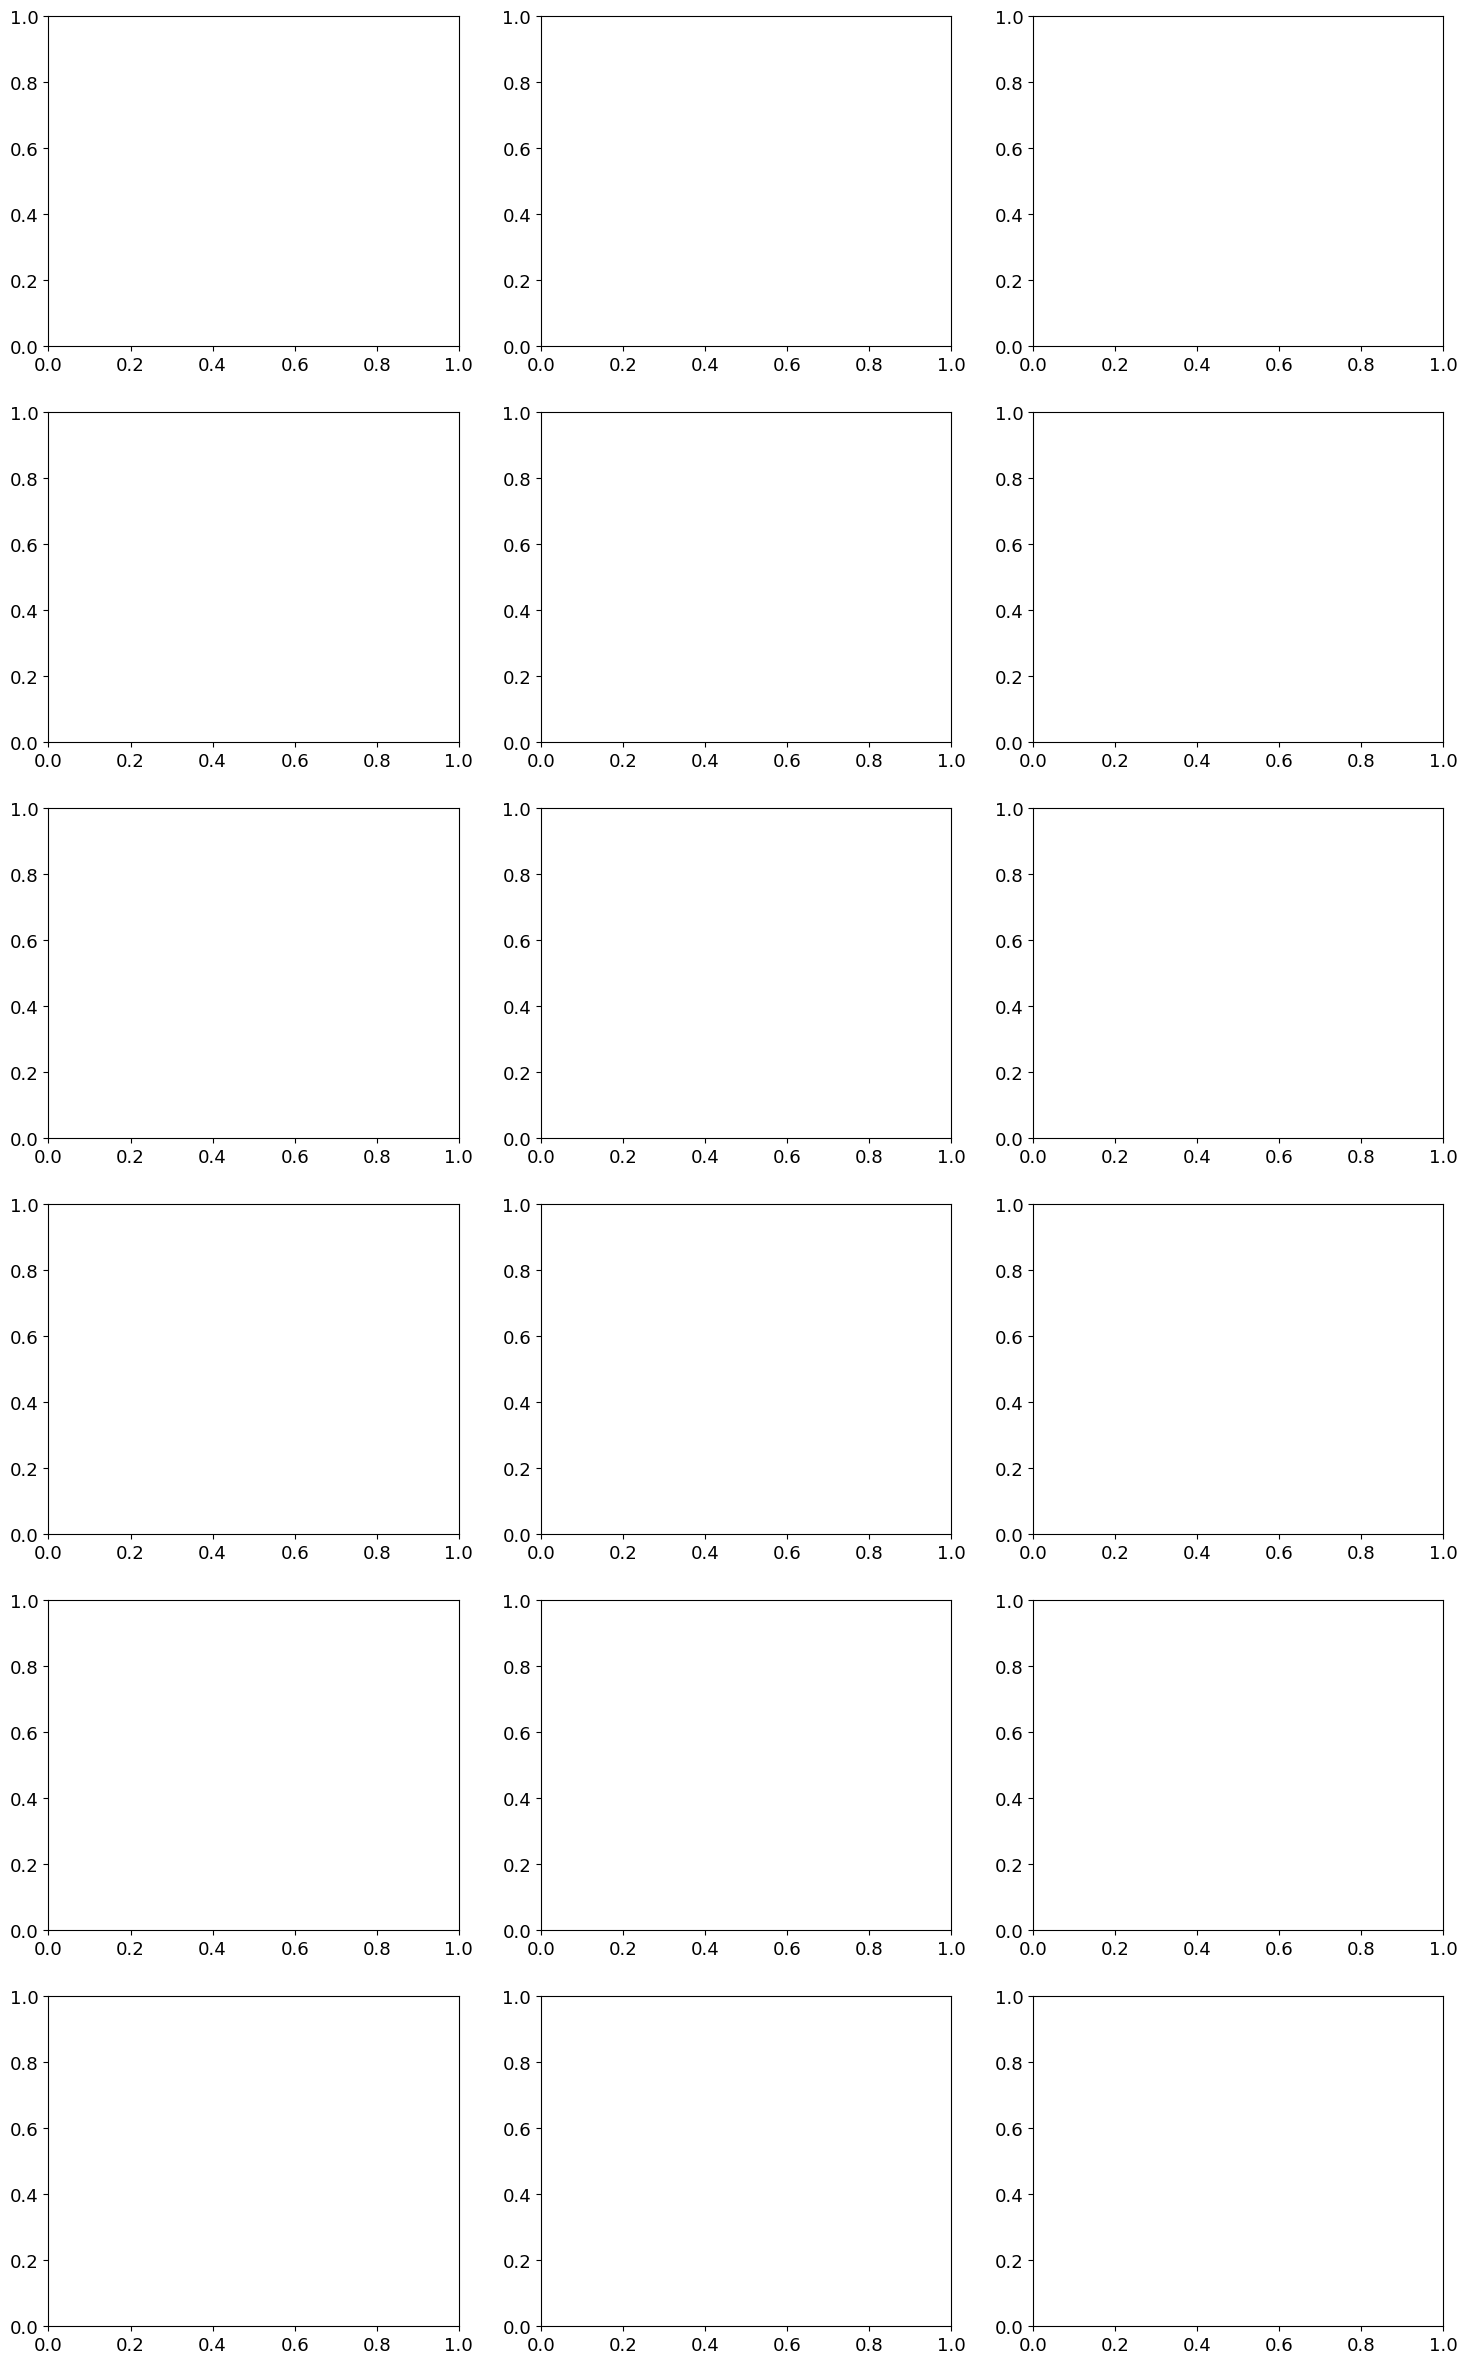

In [3]:
#SPLITTING DATASET AND SCALING
p_train_val = 0.8
N_train_val = int(N * p_train_val)

x_train_val, y_train_val = x[:N_train_val], y[:N_train_val]
x_test, y_test = x[N_train_val:], y[N_train_val:]

scaler = StandardScaler()
x_train_val = scaler.fit_transform(x_train_val)
x_test = scaler.transform(x_test)

x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_val, y_train_val, test_size=0.2, random_state=12345
)

#IPER-PARAMETERS
l_rates = [0.1 , 0.01, 0.001]
b_sizes = [32, 64]
opts = ['SGD', 'RMSprop', 'Adam']
n_epochs = 150 

n_combinations = len(l_rates) * len(b_sizes) * len(opts)
n_cols = 3
n_rows = math.ceil(n_combinations / n_cols)
fig_ind, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

best_acc = 0
results_history = [] 


In [4]:
#Vanilla


In [15]:
#TRAINING
for i, (lr) in enumerate(l_rates):
    for j, (bs) in enumerate(b_sizes):
        for k, (opt_name) in enumerate(opts):
            
            idx = i * (len(b_sizes) * len(opts)) + j * len(opts) + k
            label = f"LR:{lr}, BS:{bs}, {opt_name}"
           
            np.random.seed(12345)
            tf_r.set_seed(12345)

            model = Sequential([
                Dense(L, input_shape=(L,), activation='relu'),
                Dense(20, activation="elu"),
                Dropout(0.1),
                Dense(20, activation="elu"),
                Dropout(0.1),
                Dense(20, activation='elu'),
                Dropout(0.1),
                Dense(1, activation='sigmoid')
            ])

            if opt_name == 'Adam':
                optimizer = Adam(learning_rate=lr)
            elif opt_name == 'RMSprop':
                optimizer = RMSprop(learning_rate=lr)
            elif opt_name == 'SGD':
                optimizer = SGD(learning_rate=lr)
            model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

            fit = model.fit(
                x_train, y_train,
                epochs=n_epochs,
                batch_size=bs,
                validation_data=(x_valid, y_valid),
                verbose=0
            )

            train_acc_final = fit.history['accuracy'][-1]
            val_acc_final = fit.history['val_accuracy'][-1]
            
            results_history.append({
                'label': label,
                'train_acc': fit.history['accuracy'],
                'val_acc': fit.history['val_accuracy'],
                'final_val_acc': val_acc_final
            })

            if val_acc_final > best_acc:
                best_acc = val_acc_final
                best_model = model
                best_params_label = label

            ax = axes[idx]
            ax.plot(fit.history['accuracy'], label="Train", ls="--", alpha=0.7)
            ax.plot(fit.history['val_accuracy'], label="Valid")
            ax.set_title(label, fontsize=10)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Accuracy")
            ax.legend(prop={'size': 8})
            ax.grid(True, alpha=0.2)

for i in range(idx + 1, len(axes)):
    fig_ind.delaxes(axes[i])

fig_ind.tight_layout()
plt.show()


/home/niccolo/.local/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


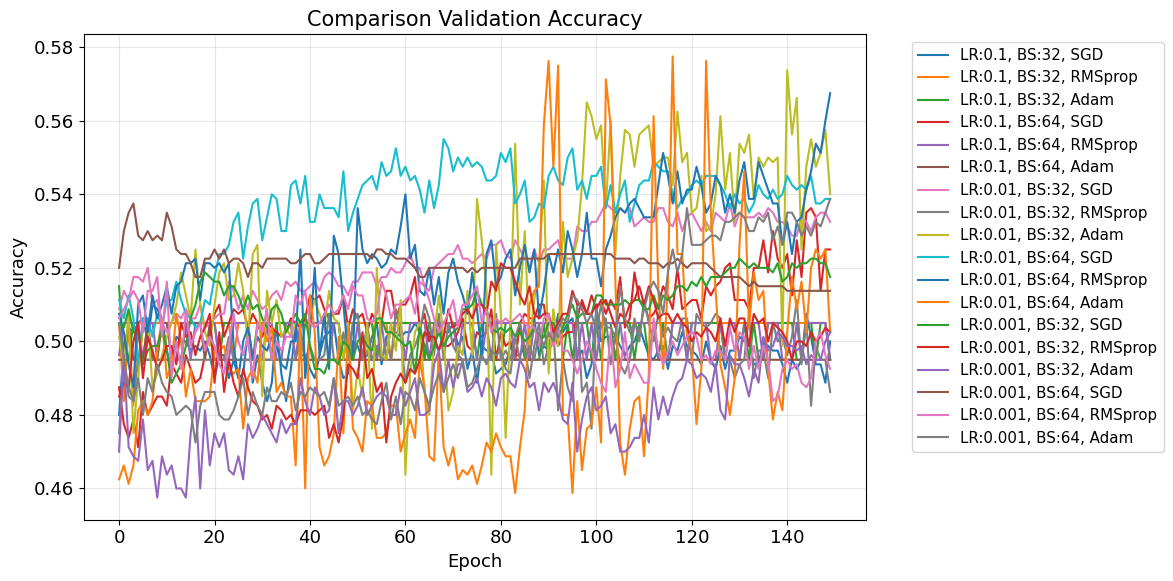


FINAL RESULT:
Best Configuration: LR:0.01, BS:64, RMSprop
Test Accuracy: 0.6000


In [16]:
#COMPARISON AND TEST
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)

plt.figure(figsize=(12, 6))
for res in results_history:
    plt.plot(res['val_acc'], label=res['label'], lw=1.5)

plt.title("Comparison Validation Accuracy", fontsize=15)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFINAL RESULT:\nBest Configuration: {best_params_label}")
print(f"Test Accuracy: {test_acc:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


<Figure size 700x500 with 0 Axes>

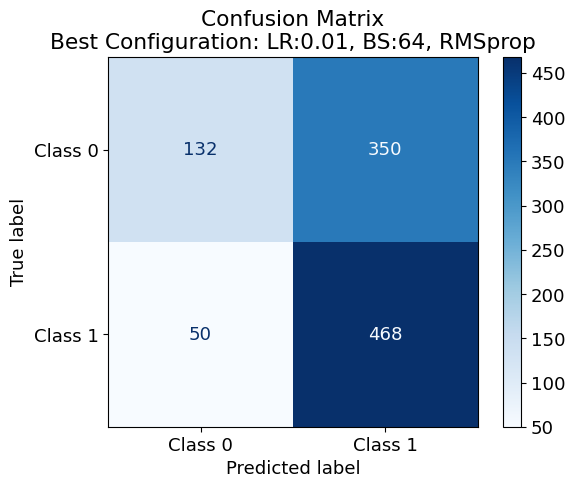


--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.73      0.27      0.40       482
           1       0.57      0.90      0.70       518

    accuracy                           0.60      1000
   macro avg       0.65      0.59      0.55      1000
weighted avg       0.65      0.60      0.55      1000



In [ ]:
y_probs = best_model.predict(x_test)
y_pred = (y_probs > 0.5).astype(int) # Trasformiamo le probabilità in classi 0 o 1

# 2. Calcolare la matrice di confusione
cm = confusion_matrix(y_test, y_pred)

# 3. Rappresentazione grafica
plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, values_format='d') # 'd' per visualizzare numeri interi

plt.title(f"Confusion Matrix\nBest Configuration: {best_params_label}")
plt.show()

# 4. Stampare metriche dettagliate
from sklearn.metrics import classification_report
print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(y_probs[y_test==0], bins=30, alpha=0.5, label='Classe 0 (Reale)', color='red')
plt.hist(y_probs[y_test==1], bins=30, alpha=0.5, label='Classe 1 (Reale)', color='blue')
plt.axvline(0.5, color='black', linestyle='--', label='Soglia 0.5')
plt.xlabel('Probability predected from model')
plt.ylabel('Frequency')
plt.title('Distribution of prediction')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc


fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specific)')
plt.ylabel('True Positive Rate (Sensibility)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()



In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

# Calcola i tassi di errore per ogni possibile soglia
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calcola il G-Mean per ogni soglia
gmeans = np.sqrt(tpr * (1-fpr))

# Trova l'indice della soglia migliore
ix = np.argmax(gmeans)
best_threshold = thresholds[ix]

print(f'Migliore Soglia suggerita: {best_threshold:.4f}')

# Ora usa questa per la tua Confusion Matrix
y_pred_ottimale = (y_probs > best_threshold).astype(int)

In [ ]:
y_probs = best_model.predict(x_test) 
y_pred = (y_probs > 0.4831).astype(int)

cm = confusion_matrix(y_test, y_pred)

# 3. Visualizzazione grafica
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title(f"Confusion Matrix\nBest Model: {best_params_label}")
plt.show()

from sklearn.metrics import classification_report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

In [ ]:
# EARLY STOPPING - BATCH NORM - AUGMENTATION
n_combinations = len(l_rates) * len(b_sizes) * len(opts)
n_cols = 3
n_rows = math.ceil(n_combinations / n_cols)

# Creazione della figura e della griglia di sotto-grafici
fig_ind, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()


best_acc = 0
results_history = []

for i, lr in enumerate(l_rates):
    for j, bs in enumerate(b_sizes):
        for k, opt_name in enumerate(opts):
            
            idx = i * (len(b_sizes) * len(opts)) + j * len(opts) + k
            label = f"LR:{lr}, BS:{bs}, {opt_name}"
            
            tf.random.set_seed(12345)
            np.random.seed(12345)

            model = Sequential([
                # DATA AUGMENTATION (Noise)
                GaussianNoise(0.1, input_shape=(L,)), 
                Dense(L, activation='relu'),
                # BATCH NORMALIZATION
                BatchNormalization(),
                Dense(20, activation="elu"),
                BatchNormalization(),
                Dropout(0.1),
                Dense(20, activation="elu"),
                BatchNormalization(),
                Dropout(0.1),
                Dense(20, activation='elu'),
                BatchNormalization(),
                Dropout(0.1),
                Dense(1, activation='sigmoid')
            ])

            if opt_name == 'Adam': optimizer = Adam(learning_rate=lr)
            elif opt_name == 'RMSprop': optimizer = RMSprop(learning_rate=lr)
            else: optimizer = SGD(learning_rate=lr)

            model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

            # EARLY STOPPING
            early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

            fit = model.fit(
                x_train, y_train,
                epochs=n_epochs,
                batch_size=bs,
                validation_data=(x_valid, y_valid),
                verbose=1,
                callbacks=[early_stop]
            )

            val_acc_final = max(fit.history['val_accuracy'])
            results_history.append({'label': label, 'val_acc': fit.history['val_accuracy']})

            if val_acc_final > best_acc:
                best_acc = val_acc_final
                best_model = model
                best_params_label = label

            ax = axes[idx]
            ax.plot(fit.history['accuracy'], label="Train", ls="--", alpha=0.7)
            ax.plot(fit.history['val_accuracy'], label="Valid")
            ax.set_title(label, fontsize=10)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Accuracy")
            ax.grid(True, alpha=0.2)
            ax.legend(prop={'size': 8})

for i in range(idx + 1, len(axes)):
    fig_ind.delaxes(axes[i])

fig_ind.tight_layout()
plt.show()

test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)

plt.figure(figsize=(12, 6))
for res in results_history:
    plt.plot(res['val_acc'], label=res['label'], lw=1.2, alpha=0.8)
plt.title("Comparison Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFINAL RESULT:\nBest Configuration: {best_params_label}")
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/150
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8391 - loss: 0.3849 - val_accuracy: 0.8847 - val_loss: 0.2986
Epoch 2/150
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8693 - loss: 0.3337 - val_accuracy: 0.8890 - val_loss: 0.2800
Epoch 3/150
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8778 - loss: 0.3166 - val_accuracy: 0.8949 - val_loss: 0.2625
Epoch 4/150
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8812 - loss: 0.3060 - val_accuracy: 0.8985 - val_loss: 0.2605
Epoch 5/150
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8873 - loss: 0.2968 - val_accuracy: 0.8995 - val_loss: 0.2530
Epoch 6/150
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8901 - loss: 0.2922 - val_accuracy: 0.9037 - val_loss: 0.2495
Epoch 7/150
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8901 - loss: 0.2872 - val_accuracy: 0.9070 - val_loss: 0.2447
Epoch 8/150
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8936 - loss: 0.2835 - val_accu

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


<Figure size 800x600 with 0 Axes>

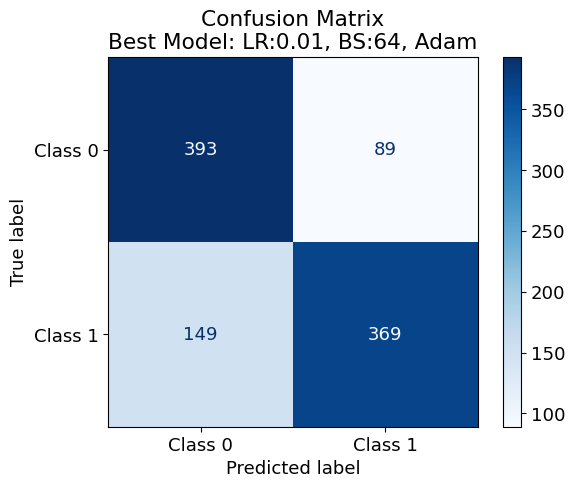


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.73      0.82      0.77       482
           1       0.81      0.71      0.76       518

    accuracy                           0.76      1000
   macro avg       0.77      0.76      0.76      1000
weighted avg       0.77      0.76      0.76      1000



In [20]:
y_probs = best_model.predict(x_test) 
y_pred = (y_probs > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

# 3. Visualizzazione grafica
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title(f"Confusion Matrix\nBest Model: {best_params_label}")
plt.show()

from sklearn.metrics import classification_report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

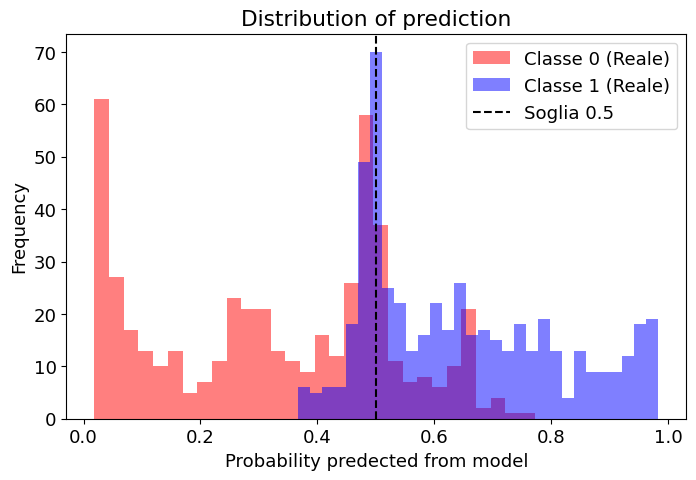

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(y_probs[y_test==0], bins=30, alpha=0.5, label='Classe 0 (Reale)', color='red')
plt.hist(y_probs[y_test==1], bins=30, alpha=0.5, label='Classe 1 (Reale)', color='blue')
plt.axvline(0.5, color='black', linestyle='--', label='Soglia 0.5')
plt.xlabel('Probability predected from model')
plt.ylabel('Frequency')
plt.title('Distribution of prediction')
plt.legend()
plt.show()

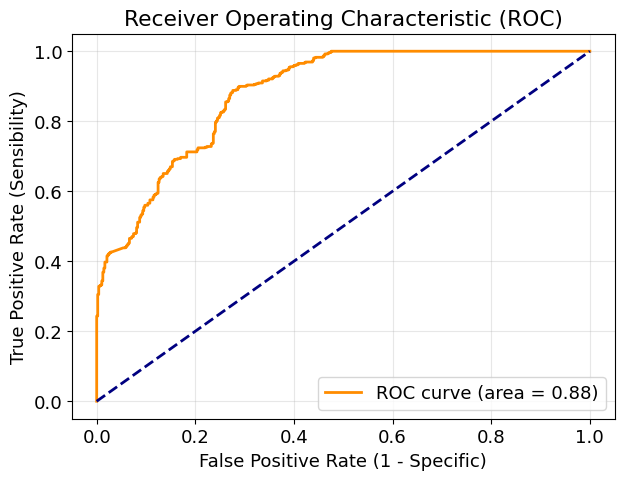

In [22]:
from sklearn.metrics import roc_curve, auc


fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specific)')
plt.ylabel('True Positive Rate (Sensibility)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

gmeans = np.sqrt(tpr * (1-fpr))

ix = np.argmax(gmeans)
best_threshold = thresholds[ix]

print(f'Migliore Soglia suggerita: {best_threshold:.4f}')

y_pred_ottimale = (y_probs > best_threshold).astype(int)

Migliore Soglia suggerita: 0.4831


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


<Figure size 800x600 with 0 Axes>

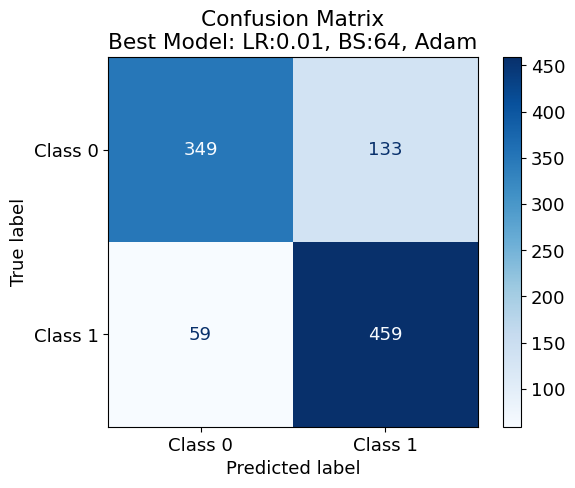


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.86      0.72      0.78       482
           1       0.78      0.89      0.83       518

    accuracy                           0.81      1000
   macro avg       0.82      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



In [32]:
y_probs = best_model.predict(x_test) 
y_pred = (y_probs > 0.4831).astype(int)

cm = confusion_matrix(y_test, y_pred)

# 3. Visualizzazione grafica
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title(f"Confusion Matrix\nBest Model: {best_params_label}")
plt.show()

from sklearn.metrics import classification_report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))